# Notebook 05 — Robust Metric Estimation from Gap Boundaries

**Pipeline:** Adaptive classical pipeline for Michelin cut-edge/gap measurement  
**Step 5:** Detected gap boundaries → 10 sampling measurements → robust metric summaries in mm

This notebook replaces the previous Hough-based metric stage and adds robust statistics so that isolated bad samples at the beginning/end of a gap do not dominate the final measurement.

**Input:**
- `outputs/04_gap_boundaries/gap_boundaries.json`
- `outputs/02_rectified/calibration.json`
- `outputs/02_rectified/*.jpg`

**Output:**
- `outputs/05_metric/measurements.json`
- `outputs/05_metric/measurements_flat.csv`
- `outputs/05_metric/samples_flat.csv`
- `outputs/05_metric/debug/measurement_overlays/`


In [1]:
from pathlib import Path
import json
import math

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries loaded")


Libraries loaded


## 1. Configuration


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
GAPS_PATH     = Path("outputs/04_gap_boundaries/gap_boundaries.json")
RECTIFIED_DIR = Path("outputs/02_rectified")
CALIB_PATH    = RECTIFIED_DIR / "calibration.json"

OUTPUT_DIR = Path("outputs/05_metric")
DEBUG_DIR  = OUTPUT_DIR / "debug"
OVERLAY_DIR = DEBUG_DIR / "measurement_overlays"
PLOTS_DIR   = DEBUG_DIR / "plots"

for d in [OUTPUT_DIR, DEBUG_DIR, OVERLAY_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Rectified images are expected to represent the 800 mm QR reference square.
QR_LEG_MM = 800.0

# Keep all gap candidates by default. Set an integer if you want to keep only
# the best N gaps per image according to the NB04 score.
KEEP_TOP_N_GAPS_PER_IMAGE = None

# Minimum number of valid samples required to summarize a gap.
MIN_VALID_SAMPLES = 3

# ── Robust metric parameters ───────────────────────────────────────────────
# If a gap has enough samples, drop the smallest and largest distance before
# computing the trimmed mean. This reduces the influence of noisy endpoints.
TRIM_EACH_SIDE = 1
TRIM_IF_N_SAMPLES_AT_LEAST = 5

# The recommended final measurement uses the trimmed mean when available.
# Otherwise it falls back to the median, and finally to the normal mean.
RECOMMENDED_DISTANCE_PRIORITY = [
    "trimmed_mean_distance_mm",
    "median_distance_mm",
    "mean_distance_mm",
]

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}

print(f"Gaps path    : {GAPS_PATH.resolve()}")
print(f"Rectified dir: {RECTIFIED_DIR.resolve()}")
print(f"Output dir   : {OUTPUT_DIR.resolve()}")
print(f"Robust trim  : remove {TRIM_EACH_SIDE} value(s) per side if n >= {TRIM_IF_N_SAMPLES_AT_LEAST}")


Gaps path    : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_gap_boundaries\gap_boundaries.json
Rectified dir: C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\02_rectified
Output dir   : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\05_metric
Robust trim  : remove 1 value(s) per side if n >= 5


## 2. Load data from previous notebooks


In [3]:
def load_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_gap_results(raw_results) -> list[dict]:
    """
    Accept both possible formats:
      - list of image records, as produced by NB04
      - dict keyed by image_name
    and return a list of image records.
    """
    if isinstance(raw_results, list):
        return raw_results

    if isinstance(raw_results, dict):
        records = []
        for key, value in raw_results.items():
            if isinstance(value, dict):
                value = value.copy()
                value.setdefault("image_name", key)
                records.append(value)
        return records

    raise TypeError(f"Unsupported gap results format: {type(raw_results)}")


raw_gap_results = load_json(GAPS_PATH)
gap_results = normalize_gap_results(raw_gap_results)

if CALIB_PATH.exists():
    raw_calibration = load_json(CALIB_PATH)
    if isinstance(raw_calibration, list):
        calibration_by_name = {item["image_name"]: item for item in raw_calibration}
    elif isinstance(raw_calibration, dict):
        calibration_by_name = raw_calibration
    else:
        calibration_by_name = {}
else:
    calibration_by_name = {}

print(f"Images with gap records : {len(gap_results)}")
print(f"Calibration records     : {len(calibration_by_name)}")

# Quick consistency check
missing_images = [r.get("image_name") for r in gap_results if not (RECTIFIED_DIR / r.get("image_name", "")).exists()]
if missing_images:
    print(f"[WARN] Missing rectified images for {len(missing_images)} records")
    print(missing_images[:10])


Images with gap records : 20
Calibration records     : 20


## 3. Metric helpers

NB04 already computes 10 samples for each gap. Here we recompute only summary statistics and keep the original sampled point pairs.


In [4]:
def safe_float(value, default=None):
    if value is None:
        return default
    try:
        value = float(value)
        if math.isnan(value) or math.isinf(value):
            return default
        return value
    except Exception:
        return default


def px_per_mm_for_record(image_record: dict) -> float:
    """
    Prefer px_per_mm from NB04. Fall back to calibration.json.
    If neither exists, assume rectified image uses 800 px = 800 mm.
    """
    image_name = image_record.get("image_name")

    px_per_mm = safe_float(image_record.get("px_per_mm"))
    if px_per_mm is not None and px_per_mm > 0:
        return px_per_mm

    calib = calibration_by_name.get(image_name, {})
    px_per_mm = safe_float(calib.get("px_per_mm"))
    if px_per_mm is not None and px_per_mm > 0:
        return px_per_mm

    img_path = RECTIFIED_DIR / image_name
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is not None:
        h, w = img.shape[:2]
        return float((w + h) / 2.0 / QR_LEG_MM)

    return 1.0


def sample_distance_mm(sample: dict, px_per_mm: float) -> float | None:
    """
    Return sample distance in mm. If NB04 already stored distance_mm,
    use it. Otherwise compute it from distance_px.
    """
    dist_mm = safe_float(sample.get("distance_mm"))
    if dist_mm is not None:
        return dist_mm

    dist_px = safe_float(sample.get("distance_px"))
    if dist_px is None or px_per_mm <= 0:
        return None

    return dist_px / px_per_mm


def trimmed_values(values: np.ndarray) -> np.ndarray:
    """
    Return values after removing the lowest and highest values.
    Used to reduce the effect of noisy samples near the ends of the detected gap.
    """
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]

    if len(values) >= TRIM_IF_N_SAMPLES_AT_LEAST and TRIM_EACH_SIDE > 0:
        sorted_values = np.sort(values)
        start = TRIM_EACH_SIDE
        end = len(sorted_values) - TRIM_EACH_SIDE

        if start < end:
            return sorted_values[start:end]

    return values


def recommended_distance(stats: dict) -> float | None:
    """
    Select the recommended final distance using a robust priority order.
    """
    for key in RECOMMENDED_DISTANCE_PRIORITY:
        value = stats.get(key)
        if value is not None and np.isfinite(value):
            return float(value)
    return None


def summarize_distances(distances_mm: list[float]) -> dict:
    arr = np.asarray(distances_mm, dtype=np.float32)
    arr = arr[np.isfinite(arr)]

    if len(arr) == 0:
        return {
            "n_valid_samples": 0,
            "mean_distance_mm": None,
            "median_distance_mm": None,
            "trimmed_mean_distance_mm": None,
            "trimmed_std_distance_mm": None,
            "recommended_distance_mm": None,
            "std_distance_mm": None,
            "min_distance_mm": None,
            "max_distance_mm": None,
            "range_distance_mm": None,
            "cv_distance": None,
            "robust_cv_distance": None,
            "n_trimmed_samples": 0,
        }

    mean = float(np.mean(arr))
    std = float(np.std(arr))
    min_v = float(np.min(arr))
    max_v = float(np.max(arr))

    trimmed = trimmed_values(arr)
    trimmed_mean = float(np.mean(trimmed)) if len(trimmed) > 0 else None
    trimmed_std = float(np.std(trimmed)) if len(trimmed) > 0 else None

    stats = {
        "n_valid_samples": int(len(arr)),
        "mean_distance_mm": mean,
        "median_distance_mm": float(np.median(arr)),
        "trimmed_mean_distance_mm": trimmed_mean,
        "trimmed_std_distance_mm": trimmed_std,
        "std_distance_mm": std,
        "min_distance_mm": min_v,
        "max_distance_mm": max_v,
        "range_distance_mm": max_v - min_v,
        "cv_distance": float(std / mean) if abs(mean) > 1e-6 else None,
        "robust_cv_distance": float(trimmed_std / trimmed_mean) if trimmed_mean is not None and abs(trimmed_mean) > 1e-6 else None,
        "n_trimmed_samples": int(len(trimmed)),
    }

    stats["recommended_distance_mm"] = recommended_distance(stats)

    return stats


## 4. Convert NB04 gaps into final metric measurements


In [5]:
def summarize_gap(gap: dict, image_name: str, px_per_mm: float, gap_index: int) -> tuple[dict, list[dict]]:
    """
    Convert one NB04 gap candidate into a final measurement record.
    Returns:
      - gap summary
      - per-sample rows for CSV export
    """
    samples = gap.get("samples", []) or []

    distances_mm = []
    sample_rows = []

    for sample in samples:
        dist_mm = sample_distance_mm(sample, px_per_mm)
        if dist_mm is not None:
            distances_mm.append(dist_mm)

        point_a = sample.get("point_a_px", [None, None])
        point_b = sample.get("point_b_px", [None, None])

        # Some intermediate files store split coordinates directly.
        if point_a == [None, None] and "point_a_x_px" in sample:
            point_a = [sample.get("point_a_x_px"), sample.get("point_a_y_px")]
        if point_b == [None, None] and "point_b_x_px" in sample:
            point_b = [sample.get("point_b_x_px"), sample.get("point_b_y_px")]

        sample_rows.append({
            "image_name": image_name,
            "gap_id": int(gap.get("gap_id", gap_index)),
            "gap_index": int(gap_index),
            "orientation": gap.get("orientation"),
            "sample_id": int(sample.get("sample_id", len(sample_rows))),
            "point_a_x_px": safe_float(point_a[0]) if len(point_a) > 0 else None,
            "point_a_y_px": safe_float(point_a[1]) if len(point_a) > 1 else None,
            "point_b_x_px": safe_float(point_b[0]) if len(point_b) > 0 else None,
            "point_b_y_px": safe_float(point_b[1]) if len(point_b) > 1 else None,
            "distance_px": safe_float(sample.get("distance_px")),
            "distance_mm": dist_mm,
        })

    stats = summarize_distances(distances_mm)

    # Mark which samples would be kept by the trimmed mean, for easier debugging.
    if distances_mm and stats["n_trimmed_samples"] < stats["n_valid_samples"]:
        arr = np.asarray(distances_mm, dtype=np.float32)
        sorted_indices = np.argsort(arr)
        keep_indices = set(sorted_indices[TRIM_EACH_SIDE:len(arr) - TRIM_EACH_SIDE].tolist())
        valid_distance_counter = 0
        for row in sample_rows:
            if row["distance_mm"] is None:
                row["used_in_trimmed_mean"] = False
                continue
            row["used_in_trimmed_mean"] = valid_distance_counter in keep_indices
            valid_distance_counter += 1
    else:
        for row in sample_rows:
            row["used_in_trimmed_mean"] = row["distance_mm"] is not None

    bbox = gap.get("bbox_px", [None, None, None, None])
    x, y, w, h = (bbox + [None, None, None, None])[:4] if isinstance(bbox, list) else (None, None, None, None)

    width_mm_from_nb04 = safe_float(gap.get("mean_width_mm"))
    mean_width_px = safe_float(gap.get("mean_width_px"))
    if width_mm_from_nb04 is None and mean_width_px is not None and px_per_mm > 0:
        width_mm_from_nb04 = mean_width_px / px_per_mm

    summary = {
        "gap_id": int(gap.get("gap_id", gap_index)),
        "gap_index": int(gap_index),
        "orientation": gap.get("orientation"),
        "bbox_px": gap.get("bbox_px"),
        "bbox_x_px": safe_float(x),
        "bbox_y_px": safe_float(y),
        "bbox_w_px": safe_float(w),
        "bbox_h_px": safe_float(h),
        "area_px": safe_float(gap.get("area_px")),
        "length_px": safe_float(gap.get("length_px")),
        "thickness_px": safe_float(gap.get("thickness_px")),
        "mean_width_px": mean_width_px,
        "mean_width_mm_nb04": width_mm_from_nb04,
        "score": safe_float(gap.get("score")),
        "valid_for_metric": stats["n_valid_samples"] >= MIN_VALID_SAMPLES,
        **stats,
        "samples": sample_rows,
    }

    return summary, sample_rows


def process_image_measurements(image_record: dict) -> tuple[dict, list[dict], list[dict]]:
    image_name = image_record["image_name"]
    px_per_mm = px_per_mm_for_record(image_record)

    gaps = image_record.get("gaps", []) or []
    gaps = sorted(gaps, key=lambda g: safe_float(g.get("score"), 0.0), reverse=True)

    if KEEP_TOP_N_GAPS_PER_IMAGE is not None:
        gaps = gaps[:KEEP_TOP_N_GAPS_PER_IMAGE]

    gap_summaries = []
    sample_rows_all = []
    flat_gap_rows = []

    for gap_index, gap in enumerate(gaps):
        summary, sample_rows = summarize_gap(
            gap=gap,
            image_name=image_name,
            px_per_mm=px_per_mm,
            gap_index=gap_index,
        )
        gap_summaries.append(summary)
        sample_rows_all.extend(sample_rows)

        flat_gap_rows.append({
            "image_name": image_name,
            "gap_id": summary["gap_id"],
            "gap_index": summary["gap_index"],
            "orientation": summary["orientation"],
            "valid_for_metric": summary["valid_for_metric"],
            "score": summary["score"],
            "bbox_x_px": summary["bbox_x_px"],
            "bbox_y_px": summary["bbox_y_px"],
            "bbox_w_px": summary["bbox_w_px"],
            "bbox_h_px": summary["bbox_h_px"],
            "area_px": summary["area_px"],
            "length_px": summary["length_px"],
            "thickness_px": summary["thickness_px"],
            "mean_width_px": summary["mean_width_px"],
            "mean_width_mm_nb04": summary["mean_width_mm_nb04"],
            "n_valid_samples": summary["n_valid_samples"],
            "n_trimmed_samples": summary["n_trimmed_samples"],
            "mean_distance_mm": summary["mean_distance_mm"],
            "median_distance_mm": summary["median_distance_mm"],
            "trimmed_mean_distance_mm": summary["trimmed_mean_distance_mm"],
            "recommended_distance_mm": summary["recommended_distance_mm"],
            "std_distance_mm": summary["std_distance_mm"],
            "trimmed_std_distance_mm": summary["trimmed_std_distance_mm"],
            "min_distance_mm": summary["min_distance_mm"],
            "max_distance_mm": summary["max_distance_mm"],
            "range_distance_mm": summary["range_distance_mm"],
            "cv_distance": summary["cv_distance"],
            "robust_cv_distance": summary["robust_cv_distance"],
        })

    valid_gaps = [g for g in gap_summaries if g["valid_for_metric"]]
    recommended_values = [g["recommended_distance_mm"] for g in valid_gaps if g["recommended_distance_mm"] is not None]
    mean_values = [g["mean_distance_mm"] for g in valid_gaps if g["mean_distance_mm"] is not None]
    trimmed_values_list = [g["trimmed_mean_distance_mm"] for g in valid_gaps if g["trimmed_mean_distance_mm"] is not None]

    image_summary = {
        "image_name": image_name,
        "px_per_mm": float(px_per_mm),
        "n_gaps": int(len(gap_summaries)),
        "n_valid_gaps": int(len(valid_gaps)),
        "image_mean_gap_width_mm": float(np.mean(mean_values)) if mean_values else None,
        "image_trimmed_mean_gap_width_mm": float(np.mean(trimmed_values_list)) if trimmed_values_list else None,
        "image_recommended_gap_width_mm": float(np.mean(recommended_values)) if recommended_values else None,
        "image_std_gap_width_mm": float(np.std(recommended_values)) if recommended_values else None,
        "measurements": gap_summaries,
    }

    return image_summary, flat_gap_rows, sample_rows_all


## 5. Visualisation helpers


In [6]:
def color_for_id(idx: int) -> tuple[int, int, int]:
    """Return BGR color for OpenCV drawing."""
    palette = [
        (0, 255, 255),    # yellow
        (0, 165, 255),    # orange
        (255, 255, 0),    # cyan
        (0, 255, 0),      # green
        (255, 0, 255),    # magenta
        (255, 0, 0),      # blue
        (0, 0, 255),      # red
    ]
    return palette[idx % len(palette)]


def draw_measurement_overlay(image_name: str, image_summary: dict, save: bool = True):
    img_path = RECTIFIED_DIR / image_name
    img_gray = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

    if img_gray is None:
        print(f"[WARN] Could not load image for overlay: {img_path}")
        return None

    overlay = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)

    for gap_idx, measurement in enumerate(image_summary.get("measurements", [])):
        color = color_for_id(gap_idx)
        bbox = measurement.get("bbox_px")

        if isinstance(bbox, list) and len(bbox) == 4:
            x, y, w, h = [int(round(v)) for v in bbox]
            cv2.rectangle(overlay, (x, y), (x + w, y + h), color, 2)

        for sample in measurement.get("samples", []):
            ax = sample.get("point_a_x_px")
            ay = sample.get("point_a_y_px")
            bx = sample.get("point_b_x_px")
            by = sample.get("point_b_y_px")
            dist = sample.get("distance_mm")

            if None in [ax, ay, bx, by]:
                continue

            p1 = (int(round(ax)), int(round(ay)))
            p2 = (int(round(bx)), int(round(by)))

            cv2.line(overlay, p1, p2, color, 1)
            cv2.circle(overlay, p1, 3, color, -1)
            cv2.circle(overlay, p2, 3, color, -1)

        label = (
            f"{measurement['gap_id']}:{measurement.get('orientation', '?')[0]} "
            f"{measurement.get('recommended_distance_mm'):.1f}mm"
            if measurement.get("recommended_distance_mm") is not None
            else f"{measurement['gap_id']}:{measurement.get('orientation', '?')[0]} n/a"
        )

        lx = int(measurement.get("bbox_x_px") or 10)
        ly = int((measurement.get("bbox_y_px") or 10) - 5)
        ly = max(20, ly)

        cv2.putText(
            overlay,
            label,
            (lx, ly),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            color,
            1,
            cv2.LINE_AA,
        )

    if save:
        out_path = OVERLAY_DIR / f"{Path(image_name).stem}_metric_overlay.png"
        cv2.imwrite(str(out_path), overlay)

    return overlay


def show_measurement_overlay(image_name: str, metric_results: dict):
    if image_name not in metric_results:
        print(f"[WARN] No metrics for {image_name}")
        return

    overlay = draw_measurement_overlay(image_name, metric_results[image_name], save=True)

    if overlay is None:
        return

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    summary = metric_results[image_name]
    ax.set_title(
        f"{image_name} | gaps={summary['n_gaps']} | valid={summary['n_valid_gaps']} | "
        f"px/mm={summary['px_per_mm']:.3f}"
    )
    ax.axis("off")
    plt.tight_layout()
    plt.show()


## 6. Run metric summarisation


In [7]:
metric_results = {}
flat_gap_rows_all = []
sample_rows_all = []

for image_record in gap_results:
    if "image_name" not in image_record:
        print("[WARN] Skipping record without image_name")
        continue

    image_summary, flat_gap_rows, sample_rows = process_image_measurements(image_record)
    image_name = image_summary["image_name"]

    metric_results[image_name] = image_summary
    flat_gap_rows_all.extend(flat_gap_rows)
    sample_rows_all.extend(sample_rows)

    draw_measurement_overlay(image_name, image_summary, save=True)

    print(
        f"[OK] {image_name:25s} "
        f"gaps={image_summary['n_gaps']:2d} "
        f"valid={image_summary['n_valid_gaps']:2d} "
        f"mean={image_summary['image_mean_gap_width_mm']}"
    )

# Save JSON for NB06
measurements_json_path = OUTPUT_DIR / "measurements.json"
with open(measurements_json_path, "w", encoding="utf-8") as f:
    json.dump(metric_results, f, indent=2)

# Save flat CSV tables
measurements_df = pd.DataFrame(flat_gap_rows_all)
samples_df = pd.DataFrame(sample_rows_all)

measurements_csv_path = OUTPUT_DIR / "measurements_flat.csv"
samples_csv_path = OUTPUT_DIR / "samples_flat.csv"

measurements_df.to_csv(measurements_csv_path, index=False)
samples_df.to_csv(samples_csv_path, index=False)

print("\nSaved:")
print(f"  {measurements_json_path.resolve()}")
print(f"  {measurements_csv_path.resolve()}")
print(f"  {samples_csv_path.resolve()}")
print(f"  overlays → {OVERLAY_DIR.resolve()}")


[OK] Multimedia_31.jpg         gaps= 2 valid= 2 mean=6.989680290222168
[OK] Multimedia_32.jpg         gaps= 2 valid= 2 mean=6.1293652057647705
[OK] Multimedia_33.jpg         gaps= 2 valid= 2 mean=7.02777624130249
[OK] Multimedia_34.jpg         gaps= 2 valid= 2 mean=6.6809515953063965
[OK] Multimedia_35.jpg         gaps= 2 valid= 2 mean=11.2158842086792
[OK] Multimedia_36.jpg         gaps= 2 valid= 2 mean=11.2158842086792
[OK] Multimedia_37.jpg         gaps= 2 valid= 2 mean=8.757941722869873
[OK] Multimedia_39.jpg         gaps= 2 valid= 2 mean=8.033331394195557
[OK] Multimedia_40.jpg         gaps= 2 valid= 2 mean=9.34047269821167
[OK] Multimedia_41.jpg         gaps= 4 valid= 4 mean=9.84325885772705
[OK] Multimedia_42.jpg         gaps= 2 valid= 2 mean=3.2611204385757446
[OK] Multimedia_43.jpg         gaps= 2 valid= 2 mean=2.906342387199402
[OK] Multimedia_45.jpg         gaps= 2 valid= 2 mean=7.664273262023926
[OK] Multimedia_46.jpg         gaps= 2 valid= 2 mean=6.849193334579468
[OK] Mul

## 7. Visual check


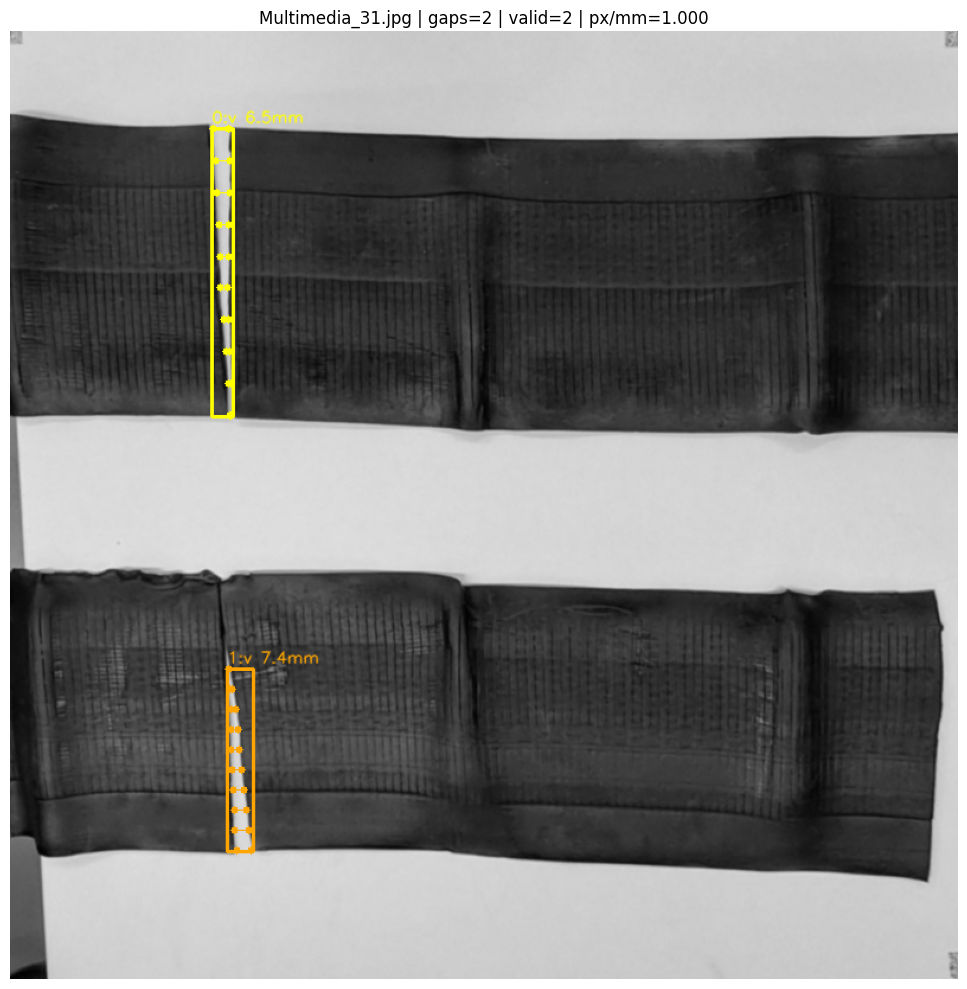

In [8]:
if metric_results:
    first_image = next(iter(metric_results.keys()))
    show_measurement_overlay(first_image, metric_results)
else:
    print("No metric results available")


## 8. Global metric summary


In [9]:
valid_measurements_df = measurements_df[measurements_df["valid_for_metric"] == True].copy() if not measurements_df.empty else pd.DataFrame()

print("Images processed:", len(metric_results))
print("Total detected gaps:", len(measurements_df))
print("Valid metric gaps:", len(valid_measurements_df))

if not valid_measurements_df.empty:
    display_cols = [
        "image_name", "gap_id", "orientation", "score",
        "mean_distance_mm", "median_distance_mm", "trimmed_mean_distance_mm",
        "recommended_distance_mm", "std_distance_mm", "trimmed_std_distance_mm",
        "min_distance_mm", "max_distance_mm", "n_valid_samples"
    ]
    display(valid_measurements_df[display_cols].head(20))

    print("\nGlobal gap width statistics using normal mean (mm):")
    print(valid_measurements_df["mean_distance_mm"].describe())

    print("\nGlobal gap width statistics using robust recommended distance (mm):")
    print(valid_measurements_df["recommended_distance_mm"].describe())
else:
    print("No valid measurements to summarize")


Images processed: 20
Total detected gaps: 32
Valid metric gaps: 32


,image_name,gap_id,orientation,score,mean_distance_mm,median_distance_mm,trimmed_mean_distance_mm,recommended_distance_mm,std_distance_mm,trimmed_std_distance_mm,min_distance_mm,max_distance_mm,n_valid_samples
0,Multimedia_31.jpg,0,vertical,725.603204,6.750789,6.396821,6.474203,6.474203,4.106362,3.419834,1.857132,13.857132,10
1,Multimedia_31.jpg,1,vertical,516.748386,7.228572,7.285713,7.357143,7.357143,3.651217,2.829320,0.857147,12.571426,10
2,Multimedia_32.jpg,0,vertical,537.449153,6.119045,5.547622,5.970235,5.970235,3.630072,2.790078,0.857147,12.571426,10
3,Multimedia_32.jpg,1,vertical,435.411965,6.139686,5.984128,6.246035,6.246035,3.093493,2.300721,0.571426,10.857147,10
4,Multimedia_33.jpg,0,vertical,732.017732,6.393650,5.500000,6.188489,6.188489,4.067634,3.219980,0.857147,13.571442,10
5,Multimedia_33.jpg,1,vertical,535.152842,7.661902,8.166660,7.970235,7.970235,3.443913,2.567124,0.857147,12.000000,10
6,Multimedia_34.jpg,0,vertical,580.540864,6.142852,5.761911,6.089282,6.089282,3.430159,2.670326,0.857132,11.857132,10
7,Multimedia_34.jpg,1,vertical,509.759133,7.219051,7.380947,7.434527,7.434527,3.345165,2.488576,0.857147,11.857147,10
8,Multimedia_35.jpg,0,horizontal,780.001479,10.688902,11.000000,10.603185,10.603185,1.843125,1.487954,8.206423,13.857117,10
9,Multimedia_35.jpg,1,horizontal,760.163026,11.742867,11.976188,11.130967,11.130967,3.146766,1.438013,8.380923,20.000000,10



Global gap width statistics using normal mean (mm):
count    32.000000
mean      7.585814
std       2.682941
min       2.733331
25%       6.134525
50%       7.353185
75%       9.475004
max      12.155560
Name: mean_distance_mm, dtype: float64

Global gap width statistics using robust recommended distance (mm):
count    32.000000
mean      7.518352
std       2.641606
min       2.738094
25%       6.059520
50%       7.395835
75%       9.352680
max      12.970241
Name: recommended_distance_mm, dtype: float64


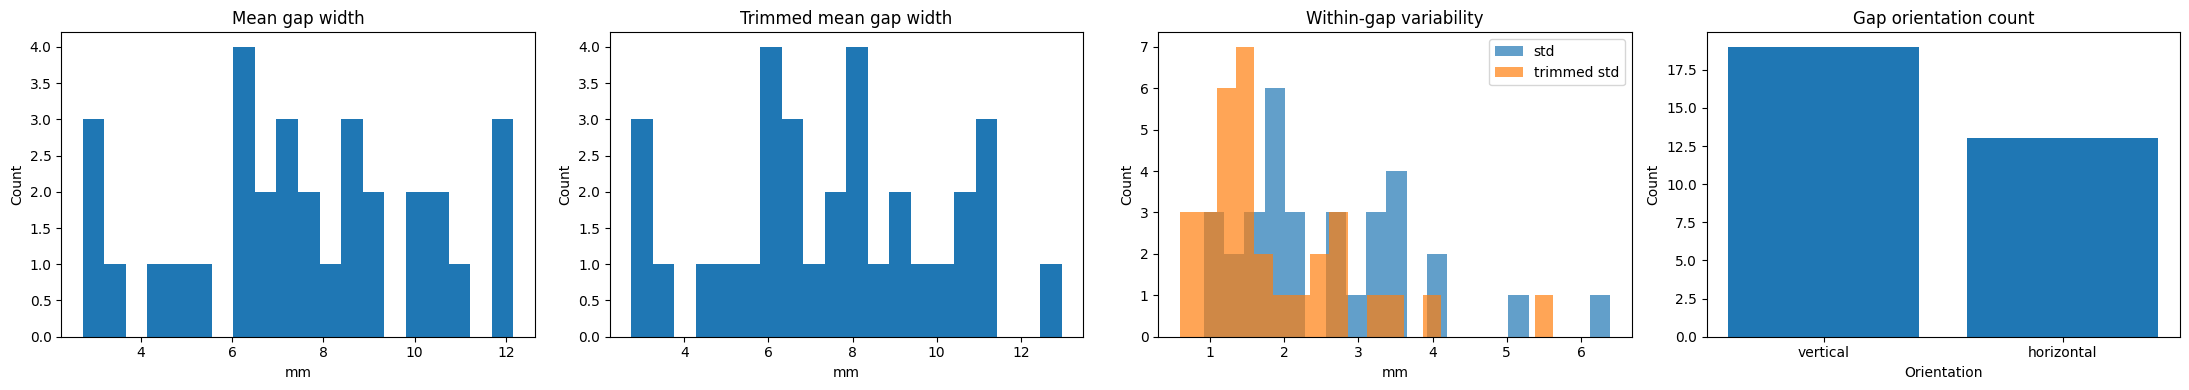

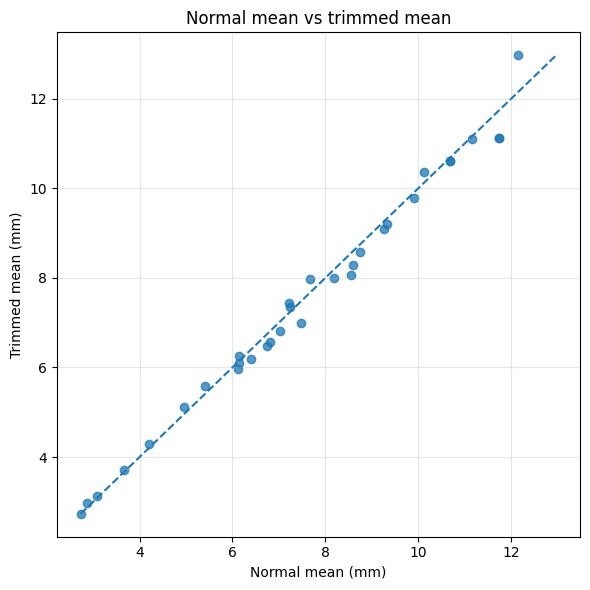

In [10]:
if not valid_measurements_df.empty:
    fig, axes = plt.subplots(1, 4, figsize=(22, 4))

    axes[0].hist(valid_measurements_df["mean_distance_mm"].dropna(), bins=20)
    axes[0].set_title("Mean gap width")
    axes[0].set_xlabel("mm")
    axes[0].set_ylabel("Count")

    axes[1].hist(valid_measurements_df["trimmed_mean_distance_mm"].dropna(), bins=20)
    axes[1].set_title("Trimmed mean gap width")
    axes[1].set_xlabel("mm")
    axes[1].set_ylabel("Count")

    axes[2].hist(valid_measurements_df["std_distance_mm"].dropna(), bins=20, alpha=0.7, label="std")
    axes[2].hist(valid_measurements_df["trimmed_std_distance_mm"].dropna(), bins=20, alpha=0.7, label="trimmed std")
    axes[2].set_title("Within-gap variability")
    axes[2].set_xlabel("mm")
    axes[2].set_ylabel("Count")
    axes[2].legend()

    orientations = valid_measurements_df["orientation"].value_counts()
    axes[3].bar(orientations.index.astype(str), orientations.values)
    axes[3].set_title("Gap orientation count")
    axes[3].set_xlabel("Orientation")
    axes[3].set_ylabel("Count")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "metric_summary_robust.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(
        valid_measurements_df["mean_distance_mm"],
        valid_measurements_df["trimmed_mean_distance_mm"],
        alpha=0.75
    )
    min_v = min(valid_measurements_df["mean_distance_mm"].min(), valid_measurements_df["trimmed_mean_distance_mm"].min())
    max_v = max(valid_measurements_df["mean_distance_mm"].max(), valid_measurements_df["trimmed_mean_distance_mm"].max())
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--")
    ax.set_title("Normal mean vs trimmed mean")
    ax.set_xlabel("Normal mean (mm)")
    ax.set_ylabel("Trimmed mean (mm)")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "mean_vs_trimmed_mean.png", dpi=150)
    plt.show()
else:
    print("No valid measurements to plot")


## 9. Summary

| Step | Operation | Detail |
|------|-----------|--------|
| 5a | Load gap detections | from `outputs/04_gap_boundaries/gap_boundaries.json` |
| 5b | Read sampled pairs | each gap contains up to 10 measurement samples |
| 5c | px → mm | uses `px_per_mm` stored by NB04/NB02 |
| 5d | Summarise gap width | mean, median, std, min, max and range in mm |
| 5e | Robust statistics | trimmed mean and trimmed std discard the lowest/highest sample when enough samples exist |
| 5f | Recommended metric | `recommended_distance_mm` uses trimmed mean first, then median, then mean |
| 5g | Export results | JSON + CSV + debug overlays |

**Output folder:** `outputs/05_metric/`  
**Main measurements file:** `outputs/05_metric/measurements.json`  
**Recommended final value per gap:** `recommended_distance_mm`  
**Used by:** NB06 evaluation/summary
